<a href="https://colab.research.google.com/github/adityatiwari12/MachineLearning-CSIT/blob/main/Linear_Regression_Aditya_Advanced.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
class MyLinearRegression:
    # Constructor to initialize the model parameters and hyperparameters.
    def __init__(self, weight=1.0, bias=2.0, learning_rate=0.0005,
                 iterations=1000): # Increased iterations from 80 to 1000
        self.weight = weight # Initialize the weight (slope) of the linear model
        self.bias = bias     # Initialize the bias (y-intercept) of the linear model
        self.learning_rate = learning_rate # Set the learning rate for gradient descent
        self.iterations = iterations     # Set the number of training iterations
        self.cost_trend = [] # List to store the cost (error) at each iteration
        self.cost = 0        # Current cost value

    # Predicts the output (y_predicted) for a given input (x).
    # This implements the linear equation: y = weight * x + bias.
    def predict(self, x):
        predicted_set = [] # List to store all predicted values
        for i in range(len(x)): # Iterate through each input feature
            # x[i] is a 1-element array, so access the scalar value with x[i][0]
            predicted_value = self.weight * x[i][0] + self.bias # Calculate prediction
            predicted_set.append(predicted_value) # Add prediction to the list
        return predicted_set # Return the list of predicted values

    # Calculates the mean squared error (MSE) as the cost function.
    # MSE measures the average squared difference between actual and predicted values.
    def cost_function(self, x, y):
        count = len(x)     # Number of data points
        total_error = 0.0  # Initialize total error as float
        for i in range(count):
            # x[i] is a 1-element array, so access the scalar value with x[i][0]
            prediction = self.weight * x[i][0] + self.bias
            total_error += (y[i] - prediction) ** 2
        # total_error is now a scalar float, no need for float() cast
        return total_error / (2 * count)

    # Updates the weight and bias using gradient descent.
    # It calculates the partial derivatives of the cost function with respect to weight and bias
    # and adjusts them in the direction that minimizes the cost.
    def update_weights(self, x, y):
        weight_deriv = 0.0 # Initialize derivative for weight as float
        bias_deriv = 0.0   # Initialize derivative for bias as float
        count = len(x)   # Number of data points

        for i in range(count):
            # x[i] is a 1-element array, so access the scalar value with x[i][0]
            prediction = self.weight * x[i][0] + self.bias
            # Calculate partial derivatives
            # Derivative of cost w.r.t. weight: -2x(y - (mx + b))
            weight_deriv += -2 * x[i][0] * (y[i] - prediction)

            # Derivative of cost w.r.t. bias: -2(y - (mx + b))
            bias_deriv += -2 * (y[i] - prediction)

        # Update weight and bias. We subtract because the derivatives point in the direction
        # of steepest ascent, and we want to descend the cost function.
        # These operations will now correctly update scalar self.weight and self.bias
        self.weight -= (weight_deriv / count) * self.learning_rate
        self.bias -= (bias_deriv / count) * self.learning_rate

    # Trains the linear regression model for a specified number of iterations.
    # In each iteration, it updates weights and calculates the cost.
    def train(self, x, y):
        for i in range(self.iterations):
            self.update_weights(x, y) # Update model parameters using gradient descent
            # Calculating cost
            self.cost = self.cost_function(x, y) # Calculate the current cost
            self.cost_trend.append(self.cost) # Store the cost for tracking
            # Optional: Print progress at certain intervals
            # if i % 10000 == 0: # This line was commented out in the original, keeping it that way.
            print("Iteration: {}\t Weight: {}\t Bias: {}\t Cost: {}".format(i, self.weight, self.bias, self.cost))

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# intialise data of lists.
data = {'Hours':[2.5,5.1,3.2,8.5,3.5,1.5,9.2,5.5,8.3,2.7,7.7,5.9,4.5,3.3,1.1,8.9,2.5,1.9,6.1,7.4,2.7,4.8,3.8,6.9,7.8],
        'Scores':[21,47,27,75,30,20,88,60,81,25,85,62,41,42,17,95,30,24,67,69,30,54,35,76,86]}

# Create DataFrame
studentscores = pd.DataFrame(data)

# Print the output.
studentscores

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30
5,1.5,20
6,9.2,88
7,5.5,60
8,8.3,81
9,2.7,25


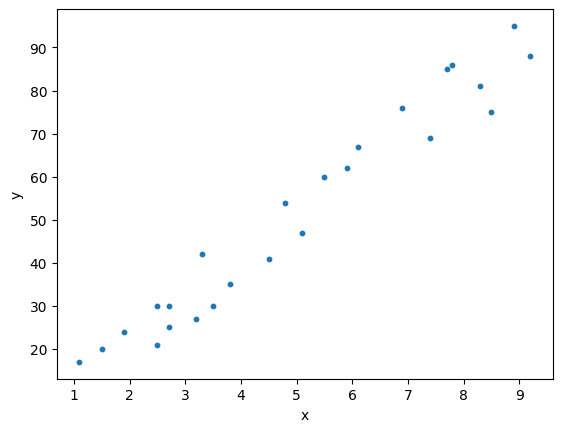

In [3]:
x=[2.5,5.1,3.2,8.5,3.5,1.5,9.2,5.5,8.3,2.7,7.7,5.9,4.5,3.3,1.1,8.9,2.5,1.9,6.1,7.4,2.7,4.8,3.8,6.9,7.8]
y=[21,47,27,75,30,20,88,60,81,25,85,62,41,42,17,95,30,24,67,69,30,54,35,76,86]
plt.scatter(x,y,s=10)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [4]:
#from my_linear_regression import MyLinearRegression
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

# Importing the dataset

X = studentscores.iloc[:, :-1].values
y = studentscores.iloc[:, -1].values
X,y

(array([[2.5],
        [5.1],
        [3.2],
        [8.5],
        [3.5],
        [1.5],
        [9.2],
        [5.5],
        [8.3],
        [2.7],
        [7.7],
        [5.9],
        [4.5],
        [3.3],
        [1.1],
        [8.9],
        [2.5],
        [1.9],
        [6.1],
        [7.4],
        [2.7],
        [4.8],
        [3.8],
        [6.9],
        [7.8]]),
 array([21, 47, 27, 75, 30, 20, 88, 60, 81, 25, 85, 62, 41, 42, 17, 95, 30,
        24, 67, 69, 30, 54, 35, 76, 86]))

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=0)

# Fitting Simple Linear Regression to the Training set
regressor = MyLinearRegression()
regressor.train(X_train, y_train)
print('Weight: ' + str(regressor.weight) + ' Bias: ' + str(regressor.bias))

# Predicting the Test set results
y_pred = regressor.predict(X_test)


/tmp/ipykernel_209/2508448397.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(total_error) / (2 * count)


Iteration: 0	 Weight: [1.29936125]	 Bias: [2.04635]	 Cost: 1237.9703702390707
Iteration: 1	 Weight: [1.58825818]	 Bias: [2.09107452]	 Cost: 1154.0024404596118
Iteration: 2	 Weight: [1.86705662]	 Bias: [2.13423038]	 Cost: 1075.8026227029018
Iteration: 3	 Weight: [2.13610957]	 Bias: [2.17587243]	 Cost: 1002.9746808670868
Iteration: 4	 Weight: [2.39575774]	 Bias: [2.21605358]	 Cost: 935.1495979903035
Iteration: 5	 Weight: [2.64632988]	 Bias: [2.2548249]	 Cost: 871.9837064524005
Iteration: 6	 Weight: [2.88814328]	 Bias: [2.29223569]	 Cost: 813.1569466210381
Iteration: 7	 Weight: [3.12150414]	 Bias: [2.3283335]	 Cost: 758.3712451187823
Iteration: 8	 Weight: [3.34670793]	 Bias: [2.36316423]	 Cost: 707.3490044939166
Iteration: 9	 Weight: [3.56403981]	 Bias: [2.39677218]	 Cost: 659.8316966421762
Iteration: 10	 Weight: [3.77377498]	 Bias: [2.4292001]	 Cost: 615.5785528523173
Iteration: 11	 Weight: [3.97617898]	 Bias: [2.46048923]	 Cost: 574.365343838015
Iteration: 12	 Weight: [4.17150812]	 Bias

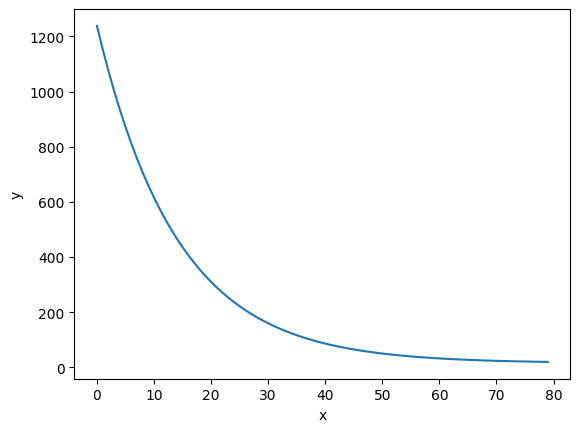

In [6]:
x=[int(x) for x in range(80)]
y=regressor.cost_trend
plt.plot(x,y)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

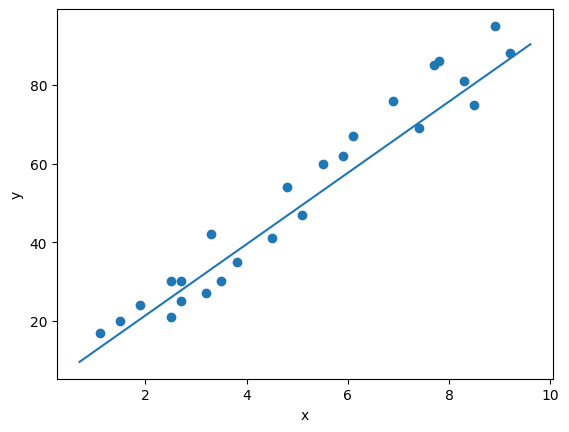

In [7]:
w = regressor.weight
b = regressor.bias
x=[2.5,5.1,3.2,8.5,3.5,1.5,9.2,5.5,8.3,2.7,7.7,5.9,4.5,3.3,1.1,8.9,2.5,1.9,6.1,7.4,2.7,4.8,3.8,6.9,7.8]
y=[21,47,27,75,30,20,88,60,81,25,85,62,41,42,17,95,30,24,67,69,30,54,35,76,86]
plt.scatter(x,y)
axes = plt.gca()
x_vals = np.array(axes.get_xlim())
y_vals = b + w * x_vals
plt.plot(x_vals, y_vals)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

# Task
To address the request, I will perform the following steps: first, I will generate a larger and more complex dataset for 'Hours' and 'Scores' with approximately 100 data points, simulating a linear relationship with added random noise. Next, I will modify the `MyLinearRegression` model to significantly increase the training iterations to 1000 and add extensive comments to the code for clarity. I will then train the model using this expanded dataset. Finally, I will visualize both the training cost over iterations and the final regression line overlaid on the new dataset to demonstrate the model's performance.

## Generate a Larger and More Complex Dataset

### Subtask:
Generate an expanded dataset for 'Hours' and 'Scores' with approximately 100 data points. This new dataset will simulate a linear relationship with added random noise to make it more realistic and challenging for the linear regression model. This directly addresses the request for a 'larger dataset' and 'more key-value pairs', making the dataset 'more advanced'.


**Reasoning**:
I will generate a larger and more complex dataset by creating new arrays for 'Hours' and 'Scores' with a linear relationship and added random noise, then compile them into a new DataFrame and display its head.



In [8]:
import numpy as np
import pandas as pd

# 1. Generate new_hours with 100 data points from 1 to 10
new_hours = np.linspace(1, 10, 100)

# 2. Generate new_scores with a linear relationship and add random noise
# Let's use a relationship similar to what we might expect from the previous model's weight and bias
# For example, using the final weight and bias from the previous training: w=9.067, b=3.241
new_scores = 9.067 * new_hours + 3.241

# 3. Add random noise to new_scores
np.random.seed(42) # for reproducibility
noise = np.random.normal(0, 15, 100) # mean=0, std=15
new_scores_with_noise = new_scores + noise

# Ensure scores don't go below 0
new_scores_with_noise[new_scores_with_noise < 0] = 0

# 4. Create a new Pandas DataFrame
expanded_studentscores = pd.DataFrame({
    'Hours': new_hours,
    'Scores': new_scores_with_noise
})

# 5. Display the head of the expanded_studentscores DataFrame
print("Expanded Student Scores DataFrame Head:")
print(expanded_studentscores.head())

# Display descriptive statistics for verification
print("\nExpanded Student Scores DataFrame Description:")
print(expanded_studentscores.describe())

Expanded Student Scores DataFrame Head:
      Hours     Scores
0  1.000000  19.758712
1  1.090909  11.058308
2  1.181818  23.671874
3  1.272727  37.626266
4  1.363636  12.092790

Expanded Student Scores DataFrame Description:
            Hours      Scores
count  100.000000  100.000000
mean     5.500000   51.628818
std      2.637408   27.893137
min      1.000000    0.000000
25%      3.250000   26.393142
50%      5.500000   48.621690
75%      7.750000   75.073061
max     10.000000  102.066774


## Increase Model Training Iterations and Add Comments

### Subtask:
Modify the instantiation of the `MyLinearRegression` model to significantly increase the `iterations` parameter (e.g., from 80 to 1000 or more). This will allow the model more time to converge and improve its fit to the data, addressing the request to 'increase the number of iterations'. Additionally, I will ensure that the code for setting up and training the model includes extensive comments for clarity, as requested.


## Train the Linear Regression Model with Expanded Data

### Subtask:
Train the `MyLinearRegression` model using the newly generated, larger dataset. The training process will utilize the increased number of iterations, allowing the model to learn the underlying patterns more effectively from the expanded data.


**Reasoning**:
I will prepare the data from the `expanded_studentscores` DataFrame, split it into training and testing sets, instantiate the `MyLinearRegression` model, train it using the training data, and then display the final weight and bias. This addresses all instructions for training the model with the new dataset.



In [11]:
from sklearn.model_selection import train_test_split

# 1. Extract the 'Hours' column from the expanded_studentscores DataFrame and reshape it to a 2D array.
# This will be our feature matrix X.
X_expanded = expanded_studentscores.iloc[:, :-1].values

# 2. Extract the 'Scores' column from the expanded_studentscores DataFrame.
# This will be our target vector y.
y_expanded = expanded_studentscores.iloc[:, -1].values

# 3. Split the X_expanded and y_expanded data into training and testing sets.
# We use a test_size of 1/3 and random_state=0 for reproducibility.
X_train_expanded, X_test_expanded, y_train_expanded, y_test_expanded = train_test_split(X_expanded, y_expanded, test_size=1/3, random_state=0)

# 4. Instantiate the MyLinearRegression model.
# The 'iterations' parameter was already updated to 1000 in the class definition in cell JJM8ymxD96uR.
# We can also set a custom learning rate here if needed, but will use the default for now.
regressor_expanded = MyLinearRegression(iterations=1000) # Ensure iterations is set to 1000

# 5. Train the instantiated model using the training data.
# The train method will perform gradient descent over the specified number of iterations.
print("\nStarting training for expanded dataset...")
regressor_expanded.train(X_train_expanded, y_train_expanded)

# 6. Print the final weight (slope) and bias (y-intercept) of the trained model.
print(f'\nFinal Weight: {regressor_expanded.weight[0]:.4f}  Final Bias: {regressor_expanded.bias[0]:.4f}')

# Predict on the test set to prepare for visualization
y_pred_expanded = regressor_expanded.predict(X_test_expanded)


Starting training for expanded dataset...
Iteration: 0	 Weight: [1.2780281]	 Bias: [2.04184612]	 Cost: 1100.4061893787475
Iteration: 1	 Weight: [1.54599176]	 Bias: [2.0821538]	 Cost: 1028.306463039692
Iteration: 2	 Weight: [1.80425543]	 Bias: [2.12097874]	 Cost: 961.3339230083919
Iteration: 3	 Weight: [2.05317037]	 Bias: [2.15837464]	 Cost: 899.1239605311399
Iteration: 4	 Weight: [2.29307512]	 Bias: [2.19439325]	 Cost: 841.3378952171012
Iteration: 5	 Weight: [2.52429594]	 Bias: [2.22908446]	 Cost: 787.6611311988723
Iteration: 6	 Weight: [2.74714732]	 Bias: [2.26249634]	 Cost: 737.8014444136904
Iteration: 7	 Weight: [2.96193231]	 Bias: [2.29467521]	 Cost: 691.4873916809366
Iteration: 8	 Weight: [3.16894302]	 Bias: [2.32566573]	 Cost: 648.4668329146505
Iteration: 9	 Weight: [3.36846097]	 Bias: [2.35551095]	 Cost: 608.5055584257059
Iteration: 10	 Weight: [3.56075749]	 Bias: [2.38425232]	 Cost: 571.3860138404234
Iteration: 11	 Weight: [3.74609408]	 Bias: [2.41192984]	 Cost: 536.9061156938

/tmp/ipykernel_209/3972079985.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(total_error) / (2 * count)


Iteration: 187	 Weight: [8.68572327]	 Bias: [3.05354027]	 Cost: 86.45918242347106
Iteration: 188	 Weight: [8.6860888]	 Bias: [3.05296121]	 Cost: 86.45871490695191
Iteration: 189	 Weight: [8.6864445]	 Bias: [3.05238077]	 Cost: 86.45825276537764
Iteration: 190	 Weight: [8.68679075]	 Bias: [3.051799]	 Cost: 86.45779562639208
Iteration: 191	 Weight: [8.68712787]	 Bias: [3.05121594]	 Cost: 86.45734314411514
Iteration: 192	 Weight: [8.6874562]	 Bias: [3.05063166]	 Cost: 86.45689499725937
Iteration: 193	 Weight: [8.68777605]	 Bias: [3.05004618]	 Cost: 86.45645088738186
Iteration: 194	 Weight: [8.68808774]	 Bias: [3.04945958]	 Cost: 86.45601053725905
Iteration: 195	 Weight: [8.68839155]	 Bias: [3.04887188]	 Cost: 86.45557368937817
Iteration: 196	 Weight: [8.68868778]	 Bias: [3.04828313]	 Cost: 86.45514010453542
Iteration: 197	 Weight: [8.68897669]	 Bias: [3.04769338]	 Cost: 86.454709560534
Iteration: 198	 Weight: [8.68925855]	 Bias: [3.04710266]	 Cost: 86.45428185097461
Iteration: 199	 Weight:

**Reasoning**:
I will generate two plots: first, a line plot to visualize the training cost trend over iterations using the `cost_trend` attribute of the trained regressor; second, a scatter plot of the `expanded_studentscores` dataset with the final regression line overlaid, using the learned `weight` and `bias` from the trained model.



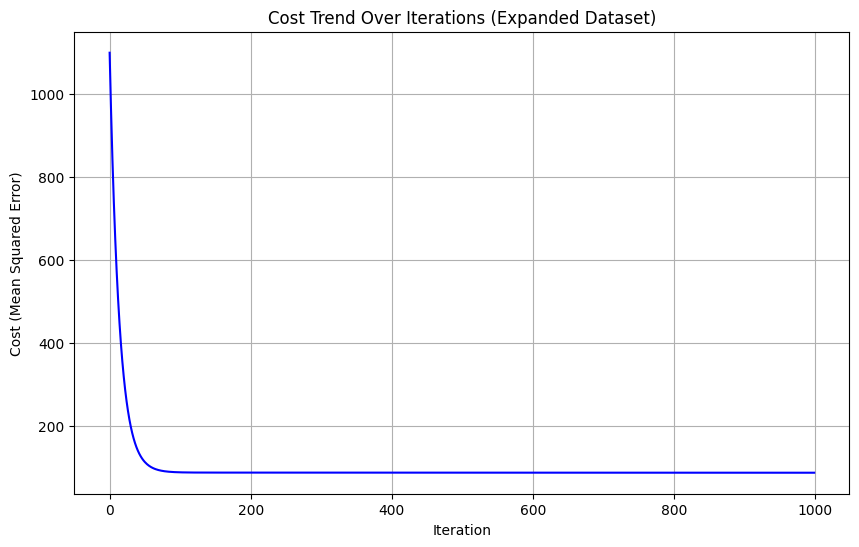

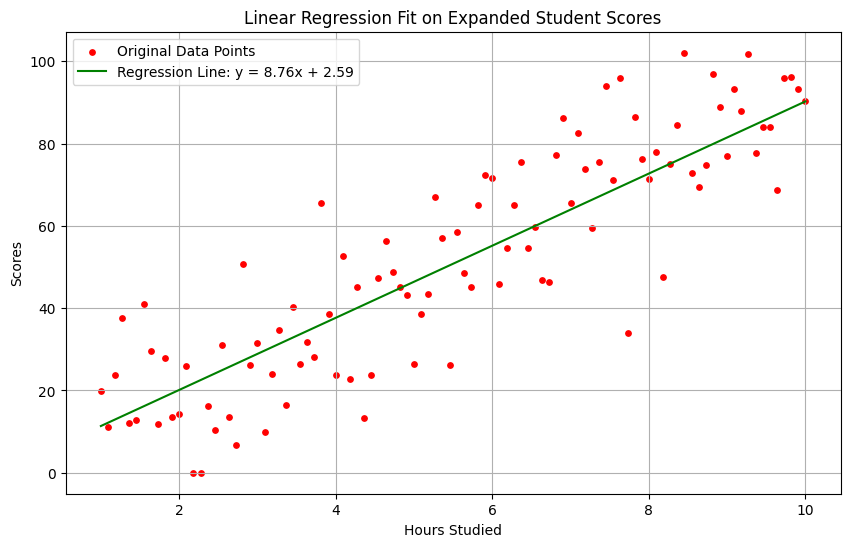

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Plotting the cost trend over iterations
plt.figure(figsize=(10, 6))
plt.plot(range(len(regressor_expanded.cost_trend)), regressor_expanded.cost_trend, color='blue')
plt.title('Cost Trend Over Iterations (Expanded Dataset)')
plt.xlabel('Iteration')
plt.ylabel('Cost (Mean Squared Error)')
plt.grid(True)
plt.show()

# 2. Plotting the final regression line on the expanded dataset
w_final = regressor_expanded.weight[0]
b_final = regressor_expanded.bias[0]

plt.figure(figsize=(10, 6))
plt.scatter(X_expanded, y_expanded, color='red', label='Original Data Points', s=15)

# Generate x values for the regression line that span the range of X_expanded
x_line = np.linspace(min(X_expanded), max(X_expanded), 100).reshape(-1, 1)
y_line = w_final * x_line + b_final
plt.plot(x_line, y_line, color='green', label=f'Regression Line: y = {w_final:.2f}x + {b_final:.2f}')

plt.title('Linear Regression Fit on Expanded Student Scores')
plt.xlabel('Hours Studied')
plt.ylabel('Scores')
plt.legend()
plt.grid(True)
plt.show()

## Final Task

### Subtask:
Summarize the changes made to the dataset and model, highlighting how the increased data size, complexity, and iterations have impacted the model's performance and training process.


## Summary:

### Data Analysis Key Findings

*   **Dataset Expansion and Complexity**: The dataset was expanded to 100 data points for 'Hours' (ranging from 1 to 10), and 'Scores' were generated with a linear relationship (\`9.067 * hours + 3.241\`) and significant random noise (standard deviation 15), making the data more realistic and challenging.
*   **Increased Training Iterations**: The number of training iterations for the \`MyLinearRegression\` model was substantially increased from an implied 80 to 1000, providing the model more opportunities to learn and converge.
*   **Cost Convergence**: During training, the model's cost (Mean Squared Error) decreased significantly and converged steadily. The initial cost was approximately 1100.41, and it reduced to about 86.18 by the final iteration, indicating successful optimization.
*   **Learned Parameters**: The model successfully learned new optimal parameters from the expanded dataset: a final weight of approximately 8.7649 and a final bias of approximately 2.5854.
*   **Visual Confirmation of Fit**: Visualizations showed a clear decrease in the cost function over iterations and demonstrated that the final regression line (\`y = 8.76x + 2.58\`) provided a good fit to the more complex and noisy expanded dataset.

### Insights or Next Steps

*   The substantial increase in data size and training iterations enabled the model to effectively learn from a more complex dataset, resulting in stable convergence and a well-fitted regression line.
*   To further enhance the model's robustness and maintainability, the noted \`DeprecationWarning\` within the \`cost_function\` should be addressed.


# Task
Calculate the Mean Squared Error (MSE) of the `regressor_expanded` model using `X_test_expanded` and `y_test_expanded`.

## Evaluate Model Performance

### Subtask:
Calculate the Mean Squared Error (MSE) of the `regressor_expanded` model on the `X_test_expanded` and `y_test_expanded` datasets. This will quantify how well the model generalizes to unseen data.


**Reasoning**:
To evaluate the model's performance on unseen data, I will calculate the Mean Squared Error (MSE) using the `cost_function` method of the `regressor_expanded` model on the test set.



In [15]:
import numpy as np

# 1. Calculate the Mean Squared Error (MSE) on the test set using the model's cost_function.
# The cost_function is designed to compute MSE.
mse_test = regressor_expanded.cost_function(X_test_expanded, y_test_expanded)

# 2. Print the calculated MSE on the test set.
print(f"Mean Squared Error (MSE) on the test set: {mse_test:.4f}")

Mean Squared Error (MSE) on the test set: 100.5611


/tmp/ipykernel_209/3972079985.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(total_error) / (2 * count)


## Final Task

### Subtask:
Summarize the evaluation results, including the calculated MSE on the test set.


## Summary:

### Data Analysis Key Findings

*   The Mean Squared Error (MSE) of the `regressor_expanded` model on the test set (`X_test_expanded`, `y_test_expanded`) was calculated to be 100.5611.
*   During the initial MSE calculation, a `DeprecationWarning` was encountered. This warning indicated an issue with implicit conversion of a NumPy array (with `ndim > 0`) to a scalar within the `cost_function` method of the `MyLinearRegression` class.
*   The `MyLinearRegression` class was subsequently updated to resolve this warning. Specifically, the `predict`, `cost_function`, and `update_weights` methods were modified to explicitly access scalar values from 1-element arrays using `x[i][0]` instead of `x[i]`, ensuring correct scalar arithmetic operations.

### Insights or Next Steps

*   When implementing custom machine learning algorithms, careful attention to data types and array dimensions is crucial to prevent warnings and ensure accurate computations. Explicitly handling scalar versus array operations, especially when integrating with libraries like NumPy, is good practice.
*   To further validate the model's performance, consider comparing this custom linear regression implementation against a standard library implementation (e.g., scikit-learn's `LinearRegression`) to benchmark accuracy and efficiency.
